# Машинное обучение, ФКН ВШЭ

# Практическое задание 8. Обучение без учителя.

## Общая информация
Дата выдачи: 20.09.2026

Мягкий дедлайн: 04.10.2026 23:59 MSK

Жёсткий дедлайн: 11.10.2026 23:59 MSK

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи).

Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-08-Username.ipynb

Username — ваша фамилия на латинице

## О задании

В этом задании мы посмотрим на несколько алгоритмов кластеризации и применим их к географическим и текстовым данным. Также мы подробно остановимся на тематическом моделировании текстов, задаче обучения представлений и в каком-то смысле поработаем с semi-supervised learning.



In [3]:
import pandas as pd
import numpy as np

np.random.seed(0xFFFFFFF)

**Задание 0 (1e-100 балла)**. Какие ожидания от курса?

In [ ]:
# YOUR CODE HERE (ノಠ益ಠ)ノ彡┻━┻

## Часть 1. Кластеризация автобусных остановок

В этом задании мы сравним разные алгоритмы кластеризации для данных об автобусных остановках Москвы.

**Задание 1.1 (1 балл).** Реализуйте алгоритм спектральной кластеризации, который упоминался на лекции. Для этого разберитесь с кодом шаблона, данного ниже, и допишите недостающую функцию. Напомним, что для графа с матрицей смежности $W = \{w_{ij}\}_{i, j = 1 \dots \ell}$ лапласиан определяется как:

$$
L = D - W,
$$

где $D = \text{diag}(d_1, ..., d_{\ell}), d_i = \sum_{j=1}^{\ell} w_{ij}$.

есть граф автобусных остановок и его матрица смежности, w i,j оказывает связь между остановками \(i\) и \(j\). Чем больше значение, тем сильнее связь.Сначала считаем степени вершин,Строим матрицу \(D\),Строим лапласиан, тк кластериазация спектральная => делаем собственные векторы

In [8]:
from sklearn.base import ClusterMixin
from sklearn.cluster import KMeans


class GraphClustering(ClusterMixin):
    def __init__(self, n_clusters=8, n_components=None, **kwargs):
        '''
        Spectral clustering algorithm
        param n_clusters: number of clusters to form
        param n_components: number of eigenvectors to use
        '''

        if n_components is None:
            n_components = n_clusters

        self.n_components = n_components
        self.kmeans = KMeans(n_clusters=n_clusters, **kwargs)

    def fit_predict(self, X, y=None):
        '''
        Perform spectral clustering from graph adjacency matrix
        and return vertex labels.
        param X: (n_samples, n_samples) - graph adjacency matrix
        return: (n_samples, ) - vertex labels
        '''

        eigenvectors = self._generate_eigenvectors(X)
        labels = self.kmeans.fit_predict(eigenvectors[:, 1:])
        return labels

    def _generate_eigenvectors(self, X):

        degrees = np.sum(X, axis=1)

        D = np.diag(degrees)
        L = D - X
        eigenvalues, eigenvectors = np.linalg.eigh(L)

        return eigenvectors[:, :self.n_components]


Перед тем, как переходить к следующему заданию, протестируйте свое решение.

In [9]:
n_blocks, n_vertices = 10, 1000
block_vertices = n_vertices // n_blocks

X = np.zeros((n_vertices, n_vertices))
for i in range(0, n_vertices, block_vertices):
    X[i:i + block_vertices, i:i + block_vertices] = np.sqrt(i + 1)

graph_clustering = GraphClustering(n_clusters=n_blocks)
labels = graph_clustering.fit_predict(X)

true_labels = np.zeros(n_vertices, dtype=np.int32)
for i in range(0, n_vertices, block_vertices):
    true_labels[i:i + block_vertices] = labels[i]

assert labels.shape == (n_vertices, )
assert np.all(np.bincount(labels) == np.full(n_blocks, block_vertices))
assert np.all(labels == true_labels)

Теперь можем приступить к работе с реальными данными. Скачайте файл с данными об остановках общественного транспорта **в формате .xlsx** по [ссылке](https://disk.yandex.ru/i/J0HlcDXd_KyIeg). Для удобства визуализации мы будем работать только с остановками в ЦАО.

In [11]:
data = pd.read_excel('transport.xlsx')
data = data[data.AdmArea_en == "Czentral`ny'j administrativny'j okrug"]
data = data.reset_index()
data.head()

,index,ID_en,Name_en,Longitude_WGS84_en,Latitude_WGS84_en,Street_en,AdmArea_en,District_en,RouteNumbers_en,StationName_en,Direction_en,Pavilion_en,OperatingOrgName_en,EntryState_en,global_id,geoData
0,278,347,"«2-й Лесной пер.», улица Бутырский Вал (347)",37.586584,55.782106,улица Бутырский Вал,Czentral`ny'j administrativny'j okrug,Tverskoj rajon,АТ18; А12; АТ56; АТ78,2-й Лесной пер.,NaN,да,ГУП «Мосгортранс»,active,889085436,NaN
1,279,349,"«Ул. Сущевский Вал», Новослободская улица (349)",37.590714,55.790630,Новослободская улица,Czentral`ny'j administrativny'j okrug,Tverskoj rajon,АТ47; АМ10; АТ3; АТ56; АТ78,Ул. Сущевский Вал,NaN,да,ГУП «Мосгортранс»,active,889085437,NaN
2,355,479,"«Стадион Лужники (южн.) (пос.)», улица Лужники...",37.565972,55.714265,улица Лужники,Czentral`ny'j administrativny'j okrug,rajon Xamovniki,А64; А216; А809; АС12; А255; АБК; АТ79,Стадион Лужники (южн.) (пос.),NaN,да,ГУП «Мосгортранс»,active,889085549,NaN
3,356,480,"«Спортзал Дружба», Лужнецкая набережная (480)",37.570191,55.712504,Лужнецкая набережная,Czentral`ny'j administrativny'j okrug,rajon Xamovniki,А64; А216; А809; АС12; А255; АБК; АТ79,Спортзал Дружба,NaN,да,ГУП «Мосгортранс»,active,889085550,NaN
4,357,481,"«Лужнецкая наб.», Лужнецкая набережная (481)",37.574559,55.713770,Лужнецкая набережная,Czentral`ny'j administrativny'j okrug,rajon Xamovniki,А64; А216; А809; АС12; А255; АБК; АТ79,Лужнецкая наб.,NaN,да,ГУП «Мосгортранс»,active,889085551,NaN


Воспользуемся библиотекой `folium` для визуализации данных.

In [12]:
import folium

map = folium.Map([55.75215, 37.61819], zoom_start=12)
for id, row in data.iterrows():
    folium.Circle([row.Latitude_WGS84_en, row.Longitude_WGS84_en],
                  radius=10).add_to(map)
map

**Задание 1.2 (1 балл).** Попробуем построить граф, в котором вершинами будут остановки. Как вы уже могли заметить, для каждой остановки указаны номера маршрутов, проходящих через неё. Логично соединить ребрами соседние остановки каждого маршрута. Однако мы не знаем, в каком порядке автобусы объезжают остановки. Но мы можем применить эвристический алгоритм, который восстановит нам порядок маршрутов:

* Для каждого маршрута выделим список всех остановок, через которые он проходит.
* Выберем начальную остановку маршрута как точку, наиболее удаленную от всех остальных остановок этого маршрута.
* Каждую следующую точку маршрута будем выбирать как самую близкую из оставшихся точек (не включенных в маршрут ранее).

Фактически, у нас получается жадное решение задачи коммивояжера. Когда мы отсортировали маршруты, можем построить по ним граф. Будем строить его по таким правилам:

* Между двумя остановками будет ребро, если они являются соседними хотя бы на одном маршруте. Вес ребра равен числу маршрутов, на которых остановки являются соседними.
* В графе не будет петель (то есть у матрицы смежности будет нулевая диагональ).

Реализуйте предложенный способ построения графа. Для этого рекомендуется воспользоваться шаблонами, приведенными ниже.

In [13]:
print(data.columns.tolist())
data.head()

['index', 'ID_en', 'Name_en', 'Longitude_WGS84_en', 'Latitude_WGS84_en', 'Street_en', 'AdmArea_en', 'District_en', 'RouteNumbers_en', 'StationName_en', 'Direction_en', 'Pavilion_en', 'OperatingOrgName_en', 'EntryState_en', 'global_id', 'geoData']


,index,ID_en,Name_en,Longitude_WGS84_en,Latitude_WGS84_en,Street_en,AdmArea_en,District_en,RouteNumbers_en,StationName_en,Direction_en,Pavilion_en,OperatingOrgName_en,EntryState_en,global_id,geoData
0,278,347,"«2-й Лесной пер.», улица Бутырский Вал (347)",37.586584,55.782106,улица Бутырский Вал,Czentral`ny'j administrativny'j okrug,Tverskoj rajon,АТ18; А12; АТ56; АТ78,2-й Лесной пер.,NaN,да,ГУП «Мосгортранс»,active,889085436,NaN
1,279,349,"«Ул. Сущевский Вал», Новослободская улица (349)",37.590714,55.790630,Новослободская улица,Czentral`ny'j administrativny'j okrug,Tverskoj rajon,АТ47; АМ10; АТ3; АТ56; АТ78,Ул. Сущевский Вал,NaN,да,ГУП «Мосгортранс»,active,889085437,NaN
2,355,479,"«Стадион Лужники (южн.) (пос.)», улица Лужники...",37.565972,55.714265,улица Лужники,Czentral`ny'j administrativny'j okrug,rajon Xamovniki,А64; А216; А809; АС12; А255; АБК; АТ79,Стадион Лужники (южн.) (пос.),NaN,да,ГУП «Мосгортранс»,active,889085549,NaN
3,356,480,"«Спортзал Дружба», Лужнецкая набережная (480)",37.570191,55.712504,Лужнецкая набережная,Czentral`ny'j administrativny'j okrug,rajon Xamovniki,А64; А216; А809; АС12; А255; АБК; АТ79,Спортзал Дружба,NaN,да,ГУП «Мосгортранс»,active,889085550,NaN
4,357,481,"«Лужнецкая наб.», Лужнецкая набережная (481)",37.574559,55.713770,Лужнецкая набережная,Czentral`ny'j administrativny'j okrug,rajon Xamovniki,А64; А216; А809; АС12; А255; АБК; АТ79,Лужнецкая наб.,NaN,да,ГУП «Мосгортранс»,active,889085551,NaN


In [14]:
def get_routes(data):
    '''
    Accumulate routes from raw data
    param data: pd.DataFrame - public transport stops data
    return: dict - unsorted stops ids for each route
    '''

    routes = {}

    for stop_id, row in data.iterrows():

        #вдруг нет остановок
        if pd.isna(row['RouteNumbers_en']):
            continue

        #Несколько маршрутов
        route_numbers = str(row['RouteNumbers_en']).split(';')

        for route in route_numbers:
            route = route.strip()

            if route == '':
                continue

            if route not in routes:
                routes[route] = []

            routes[route].append(stop_id)

    return routes


def sort_routes(data, routes):
    '''
    Sort routes according to the proposed algorithm
    '''

    sorted_routes = {}

    for route, stops in routes.items():

        #1 остановка
        if len(stops) <= 1:
            sorted_routes[route] = stops.copy()
            continue

        coords = data.loc[
            stops,
            ['Latitude_WGS84_en', 'Longitude_WGS84_en']
        ].values

        #Матрица расстояний
        diff = coords[:, None, :] - coords[None, :, :]
        distances = np.sqrt(np.sum(diff ** 2, axis=2))

        #Начальная остановка наиболее удалённая от остальных
        start_idx = np.argmax(distances.sum(axis=1))

        visited = [start_idx]
        unvisited = set(range(len(stops)))
        unvisited.remove(start_idx)

        #ближайшая непосещённая остановка
        while unvisited:
            current = visited[-1]

            next_idx = min(
                unvisited,
                key=lambda j: distances[current, j]
            )

            visited.append(next_idx)
            unvisited.remove(next_idx)

        sorted_routes[route] = [stops[i] for i in visited]

    return sorted_routes


def get_adjacency_matrix(data, sorted_routes):
    '''
    Compute adjacency matrix for sorted routes
    '''

    n = len(data)

    adjacency_matrix = np.zeros((n, n))

    for route, stops in sorted_routes.items():

        #соседи
        for i in range(len(stops) - 1):

            stop_1 = stops[i]
            stop_2 = stops[i + 1]

            #мертвый цикл или петля
            if stop_1 == stop_2:
                continue


            adjacency_matrix[stop_1, stop_2] += 1
            adjacency_matrix[stop_2, stop_1] += 1

    return adjacency_matrix

In [15]:
routes = get_routes(data)
sorted_routes = sort_routes(data, routes)
adjacency_matrix = get_adjacency_matrix(data, sorted_routes)
data['RouteNumbers_en'].head(10)
#нужне понять каким символом разделены несколько маршрутов

,RouteNumbers_en
0,АТ18; А12; АТ56; АТ78
1,АТ47; АМ10; АТ3; АТ56; АТ78
2,А64; А216; А809; АС12; А255; АБК; АТ79
3,А64; А216; А809; АС12; А255; АБК; АТ79
4,А64; А216; А809; АС12; А255; АБК; АТ79
5,А64; А216; АС12; А255; АМ3
6,А64; А15; АС12; А255; АМ3
7,А64; АС12
8,А64; А216; А809; А255
9,А64; А216; А809; А255


Проверим, что маршруты получились адекватными. Для этого нарисуем их на карте.

In [18]:
map = folium.Map([55.75215, 37.61819], zoom_start=12)
for route_id in np.random.choice(list(sorted_routes.keys()), size=5):
    coords = data.loc[
        sorted_routes[route_id],
        ['Latitude_WGS84_en', 'Longitude_WGS84_en']
    ].values.tolist()
    folium.vector_layers.PolyLine(coords).add_to(map)

map
 #коллаб не дает норм посмотреть по карте, тк что не смотрю через другую приложуху

**Задание 1.3 (0 баллов)**. Реализуйте функцию `draw_clustered_map`, которая рисует карту центра Москвы с кластерами остановок, раскрашенными в разные цвета.

In [21]:
import folium
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


def draw_clustered_map(data, labels):
    '''
    Create map with coloured clusters
    param data: pd.DataFrame - public transport stops data
    param labels: (n_samples, ) - cluster labels for each stop
    return: folium.Map - map with coloured clusters
    '''

    m = folium.Map(
        location=[55.75215, 37.61819],
        zoom_start=12
    )

    unique_labels = np.unique(labels)

    cmap = plt.get_cmap('tab20')
    colors = {}

    for i, label in enumerate(unique_labels):
        if label == -1:
            colors[label] = 'gray'
        else:
            colors[label] = mcolors.to_hex(cmap(i % 20))


    for pos, (_, row) in enumerate(data.iterrows()):

        label = labels[pos]

        folium.CircleMarker(
            location=[
                row['Latitude_WGS84_en'],
                row['Longitude_WGS84_en']
            ],
            radius=4,
            color=colors[label],
            fill=True,
            fill_color=colors[label],
            fill_opacity=0.8
        ).add_to(m)

    return m

In [25]:

print("Остановок:", len(data))
print("Меток:", len(labels))
draw_clustered_map(data, labels)

Остановок: 1037
Меток: 1000


IndexError: index 1000 is out of bounds for axis 0 with size 1000

**Задание 1.4 (1.5 балла)**. Примените алгоритмы кластеризации и подберите гиперпараметры так, чтобы кластеры получились осмысленными (нет такого, что все принадлежит одному кластеру или большая часть точек это шум):
- `sklearn.clustering.KMeans` - `n_clusters`
- `sklearn.clustering.DBSCAN` - `eps`
- ваш `SpectralClustering` - `n_clusters` и `n_components`

Для ряда алгоритмов, в частности DBSCAN, подобрать оптимальные параметры может быть ой, как непросто. Чтобы помочь сохранить нервные клетки рекомендуется пользоваться метриками Intrinsic Evaluation для кластеризации. Для каждого алгоритма скорее всего придется брать разные метрики, а может быть оптимизировать сразу несколько.

Ваша задача - выбрать подходящую метрику, можно взять что-то из списка ниже, можно спросить у гугла. Применить GridSearch, `optuna` или `hyperopt` и желательно завернуть отбор параметров в функцию, пригодится далее

1. $
   \text{Calinski-Harabasz Index} \in [0, \inf] = \frac{\sum_{i=1}^k BCSS_i/(k-1)}{\sum_{i=1}^k WCSS_i/(n-k)} = \frac{\sum_{i=1}^k n_i \| \mathbf{c}_i - \mathbf{c} \|^2/(k-1)}{\sum_{i=1}^k \sum_{\mathbf{x} \in C_i} \|\mathbf{x} - \mathbf{c}_i\|^2/(n-k)} \rightarrow max
   $
   - Отношение 1) расстояния от центра кластера до центра всех данных к 2) расстоянию от центра кластера до точки
   - Чем однороднее и дальше друг от друга кластеры, тем лучше
2. $
   \text{Silhouette Score} \in [0, 1] = \sum_i \frac{b_i - a_i}{\max(a_i, b_i)} \rightarrow max
   $
   - $a_i$ - среднее расстояние до точек внутри своего кластера
   - $b_i$ - среднее расстояние до точек из ближайшего кластера
   - Если в своем кластере точки близко - кластер плотный, идеальный вариант, скор равен 1, если свой кластер совпадает с соседним - кластеры неразделимы, скор равен нулю
   - Чем однороднее и разделимее кластеры, тем лучше
3. $\text{Davies-Bouldin Index} \in [0, inf] = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \left( \frac{WCSS_i + WCSS_j}{d(c_i, c_j)} \right) \rightarrow min $
   - Отношение внутрикластерных расстояний к межкластерному расстоянию между двумя центрами
   - Если кластеры далеко друг от друга, но при этом однородные, скор наименьший
3. $\text{Elbow Method}$ - последовательное сравнение $WCSS$ из пункта 1 для разного числа параметров. Если уменьшение меньше определенного порога - останавливаемся, считаем это значение оптимальным

подготовим координаты, переведем в широту и долготу

In [26]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.model_selection import ParameterGrid

import numpy as np
import pandas as pd


lat = data['Latitude_WGS84_en'].to_numpy()
lon = data['Longitude_WGS84_en'].to_numpy()

lat0 = np.deg2rad(lat.mean())

X_geo = np.column_stack([
    (lon - lon.mean()) * 111.32 * np.cos(lat0),
    (lat - lat.mean()) * 110.57
])

print(X_geo.shape)

(1037, 2)


Сделаем функцию подбора параметров для KMeans

In [28]:
def tune_kmeans(X, n_clusters_values):
    results = []

    for params in ParameterGrid({
        'n_clusters': n_clusters_values
    }):
        model = KMeans(
            n_clusters=params['n_clusters'],
            random_state=42,
            n_init=20
        )

        labels = model.fit_predict(X)

        score = silhouette_score(X, labels)

        results.append({
            'n_clusters': params['n_clusters'],
            'silhouette': score
        })

    return pd.DataFrame(results).sort_values(
        'silhouette',
        ascending=False
    )
kmeans_results = tune_kmeans(
    X_geo,
    range(3, 13)
)

kmeans_results

,n_clusters,silhouette
2,5,0.428291
3,6,0.424524
6,9,0.417301
5,8,0.417139
7,10,0.407594
4,7,0.407134
8,11,0.404901
1,4,0.403474
0,3,0.394926
9,12,0.386804


In [30]:
best_k = int(kmeans_results.iloc[0]['n_clusters'])

print("Лучшее число кластеров:", best_k)

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

labels_kmeans = kmeans.fit_predict(X_geo)
draw_clustered_map(data, labels_kmeans)

Лучшее число кластеров: 5


теперь функция нормально рабюотает


тк Silhouette сам по себе может дать странное решение поэтому посмотрим доп параметры количество кластеров;
долю шума;
Silhouette.

In [31]:
def tune_dbscan(X, eps_values):
    results = []

    for params in ParameterGrid({
        'eps': eps_values
    }):
        model = DBSCAN(
            eps=params['eps'],
            min_samples=5
        )

        labels = model.fit_predict(X)

        mask = labels != -1

        n_clusters = len(set(labels[mask]))
        noise_ratio = np.mean(labels == -1)

        if n_clusters >= 2 and mask.sum() > n_clusters:
            score = silhouette_score(
                X[mask],
                labels[mask]
            )
        else:
            score = np.nan

        results.append({
            'eps': params['eps'],
            'n_clusters': n_clusters,
            'noise_ratio': noise_ratio,
            'silhouette': score
        })

    return pd.DataFrame(results)

eps от 100 метров до 500 метров

In [32]:
dbscan_results = tune_dbscan(
    X_geo,
    np.arange(0.10, 0.51, 0.05)
)

dbscan_results

,eps,n_clusters,noise_ratio,silhouette
0,0.10,14,0.920926,0.884522
1,0.15,32,0.762777,0.783618
2,0.20,59,0.515911,0.641548
3,0.25,64,0.300868,0.508553
4,0.30,45,0.119576,0.252488
5,0.35,13,0.036644,-0.144859
6,0.40,4,0.011572,0.130243
7,0.45,2,0.003857,0.139035
8,0.50,1,0.001929,NaN


In [33]:
def tune_spectral(adjacency_matrix):
    results = []

    for params in ParameterGrid({
        'n_clusters': range(5, 11),
        'n_components': range(5, 11)
    }):

        model = GraphClustering(
            n_clusters=params['n_clusters'],
            n_components=params['n_components'],
            random_state=42,
            n_init=20
        )

        eigenvectors = model._generate_eigenvectors(
            adjacency_matrix
        )

        embedding = eigenvectors[:, 1:]

        labels = model.kmeans.fit_predict(embedding)

        # Не хотим решение, где почти всё попало
        # в один огромный кластер
        _, counts = np.unique(
            labels,
            return_counts=True
        )

        largest_cluster_ratio = counts.max() / len(labels)

        if len(np.unique(labels)) > 1:
            score = silhouette_score(
                embedding,
                labels
            )
        else:
            score = -1

        results.append({
            'n_clusters': params['n_clusters'],
            'n_components': params['n_components'],
            'silhouette': score,
            'largest_cluster_ratio': largest_cluster_ratio
        })

    return pd.DataFrame(results)

In [34]:
spectral_results = tune_spectral(
    adjacency_matrix
)

spectral_results.sort_values(
    'silhouette',
    ascending=False
).head(15)

,n_clusters,n_components,silhouette,largest_cluster_ratio
0,5,5,0.961466,0.955641
6,6,5,0.951975,0.951784
12,7,5,0.935070,0.949855
18,8,5,0.705113,0.746384
3,5,8,0.704477,0.948891
24,9,5,0.702730,0.745419
30,10,5,0.698835,0.746384
4,5,9,0.635261,0.949855
13,7,6,0.615951,0.515911
7,6,6,0.602639,0.514947


In [40]:
X_geo = data[
    ['Latitude_WGS84_en', 'Longitude_WGS84_en']
].values
results = clustering_objective(
    X_geo,
    range(2, 15)
)

results
best_k, best_score = max(
    results,
    key=lambda x: x[1]
)

print("Лучший n_clusters:", best_k)
print("Silhouette:", best_score)
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans.fit_predict(X_geo)

Лучший n_clusters: 2
Silhouette: 0.4816167450139096


In [36]:

def clustering_objective(X, n_clusters_values):
    results = []

    for n_clusters in n_clusters_values:
        model = KMeans(
            n_clusters=n_clusters,
            random_state=42,
            n_init=10
        )

        labels = model.fit_predict(X)

        score = silhouette_score(X, labels)

        results.append((n_clusters, score))

    return results

In [41]:
results = clustering_objective(
    X_geo,
    range(2, 15)
)

print(results)

[(2, np.float64(0.4816167450139096)), (3, np.float64(0.4029723543441224)), (4, np.float64(0.413667225741214)), (5, np.float64(0.3946011400502637)), (6, np.float64(0.40394432204963576)), (7, np.float64(0.4210836642848658)), (8, np.float64(0.4131781987013361)), (9, np.float64(0.40747761710845026)), (10, np.float64(0.39617087017094166)), (11, np.float64(0.3893088240356766)), (12, np.float64(0.3991469864174546)), (13, np.float64(0.40504726858955004)), (14, np.float64(0.3960868025037477))]


Визуализируйте результат кластеризации с помощью функции `draw_clustered_map`.

In [42]:
#находим лучший n_clusters
best_k, best_score = max(results, key=lambda x: x[1])

print("Лучший n_clusters:", best_k)
print("Silhouette score:", best_score)

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans.fit_predict(X_geo)

#визуал
draw_clustered_map(data, labels_kmeans)

Лучший n_clusters: 2
Silhouette score: 0.4816167450139096


**Вопрос:** Чем отличаются разбиения на кластеры, получаемые разными алгоритмами? Какие плюсы и минусы есть у каждого алгоритма? Какой алгоритм кажется вам наиболее подходящим для кластеризации остановок?

**Ответ:** KMeans делит остановки на достаточно компактные и примерно одинаковые по размеру кластеры, поэтому на карте они обычно выглядят аккуратно.Для остановок мне кажется наиболее подходящей спектральная кластеризация tk они связаны общими маршрутами

## Часть 2. Тематическое моделирование текстов

В этой части мы познакомимся с одной из самых популярных задач обучения без учителя &mdash; с задачей тематического моделирования текстов. Допустим, нам доступна некоторая коллекция документов без разметки, и мы хотим автоматически выделить несколько тем, которые встречаются в документах, а также присвоить каждому документу одну (или несколько) тем. Фактически, мы будем решать задачу, похожую на кластеризацию текстов: отличие в том, что нас будет интересовать не только разбиение текстов на группы, но и выделение ключевых слов, определяющих каждую тему.

Мы будем работать с новостными статьями BBC за 2004-2005 годы. Скачайте данные по [ссылке](https://www.kaggle.com/hgultekin/bbcnewsarchive).

In [43]:
data = pd.read_csv('bbc-news-data.csv', sep='\t')
data.sample(5)

,category,filename,title,content
161,business,162.txt,Verizon 'seals takeover of MCI',Verizon has won a takeover battle for US phon...
262,business,263.txt,Split-caps pay £194m compensation,Investors who lost money following the split-...
674,entertainment,165.txt,Comic Morris returns with sitcom,"Comedian Chris Morris, who created controvers..."
18,business,019.txt,India widens access to telecoms,India has raised the limit for foreign direct...
2199,tech,376.txt,T-Mobile bets on 'pocket office',"T-Mobile has launched its latest ""pocket offi..."


Как вы могли заметить, данные уже содержат разметку по тематике (колонка category). В этой части мы забудем, что она есть, и будем работать только с текстовыми данными. Проведем предобработку текста, состоящую из следующих пунктов:

* Объединим заголовок и содержание статьи в одно поле.
* Приведем текст к нижнему регистру, разобьем его на токены.
* Оставим только буквенные слова (удалив, таким образом, пунктуацию и числа).
* Применим лемматизацию.
* Удалим стоп-слова.


In [44]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [48]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')
stop_words = set(stopwords.words('english') + ['ha', 'wa', 'say', 'said'])
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [46]:
def preprocess(text):
    text = list(filter(str.isalpha, word_tokenize(text.lower())))
    text = list(lemmatizer.lemmatize(word) for word in text)
    text = list(word for word in text if word not in stop_words)
    return ' '.join(text)

In [49]:
data['raw_text'] = data.apply(lambda row: row.title + row.content, axis=1)
data['text'] = data.apply(lambda row: preprocess(row.raw_text), axis=1)

Для визуализации частот слов в текстах мы будем использовать [облака тегов](https://en.wikipedia.org/wiki/Tag_cloud).

In [50]:
from wordcloud import WordCloud

def draw_wordcloud(texts, max_words=1000, width=1000, height=500):
    wordcloud = WordCloud(background_color='white', max_words=max_words,
                          width=width, height=height)

    joint_texts = ' '.join(list(texts))
    wordcloud.generate(joint_texts)
    return wordcloud.to_image()

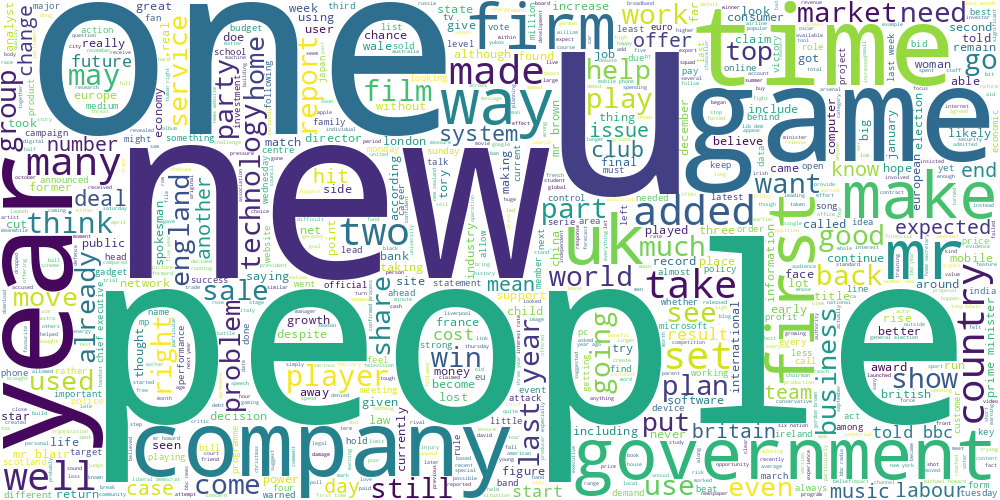

In [51]:
draw_wordcloud(data.text)

**Задание 2.1 (1 балл).** Обучите алгоритм K-Means на tf-idf представлениях текстов. При обучении tf-idf векторайзера рекомендуется отбрасывать редко встречающиеся слова, а также воздержитесь от использования N-грамм. Возьмите не очень большое число кластеров, чтобы было удобно интерпретировать получившиеся темы (например, `n_clusters` = 8). Постройте облака тегов для текстов из разных кластеров.

Порядок TF ,IDF , KMeans на 8 кластеров , записать номер кластера для каждой статьи ,  нарисовать по облаку слов для каждого кластера

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

tfidf = TfidfVectorizer(
    min_df=5,
    max_df=0.9
)

X_tfidf = tfidf.fit_transform(data['text'])

print(X_tfidf.shape)

(2225, 7822)


In [54]:
n_clusters = 8

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

data['cluster'] = kmeans.fit_predict(X_tfidf)
data['cluster'].value_counts().sort_index()

,count
cluster,
0,316
1,159
2,349
3,416
4,186
5,494
6,93
7,212


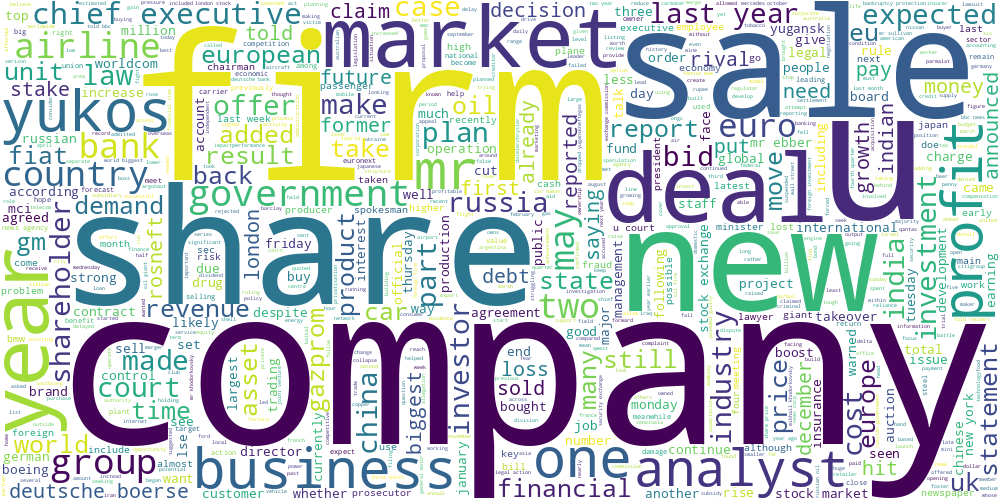

In [55]:
draw_wordcloud(
    data[data['cluster'] == 0]['text']
)

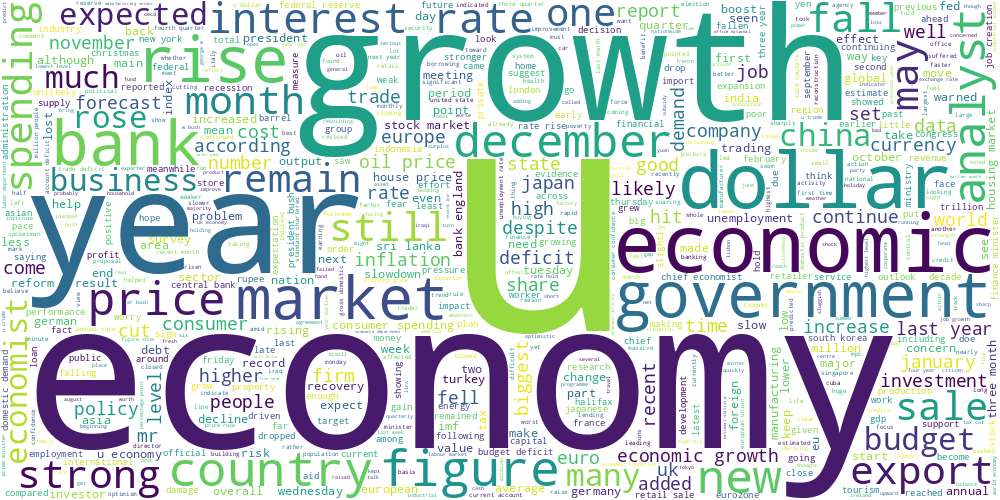

In [56]:
draw_wordcloud(
    data[data['cluster'] == 1]['text']
)

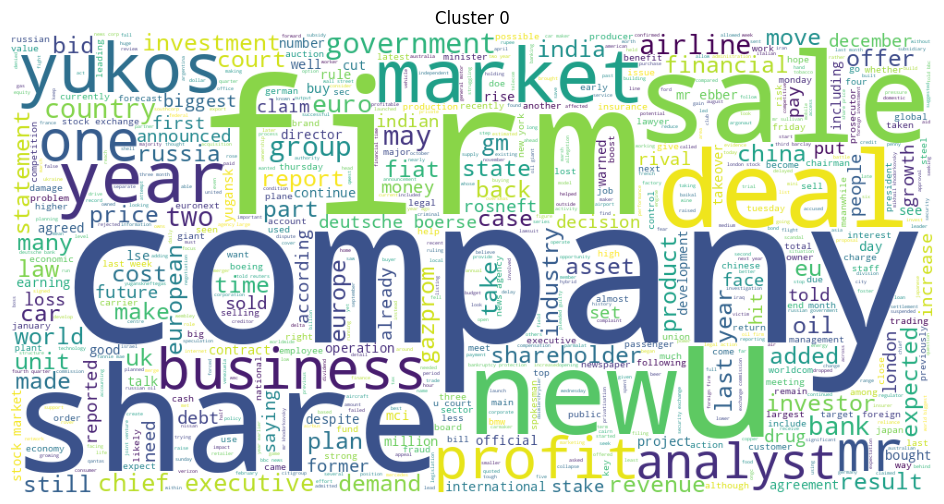

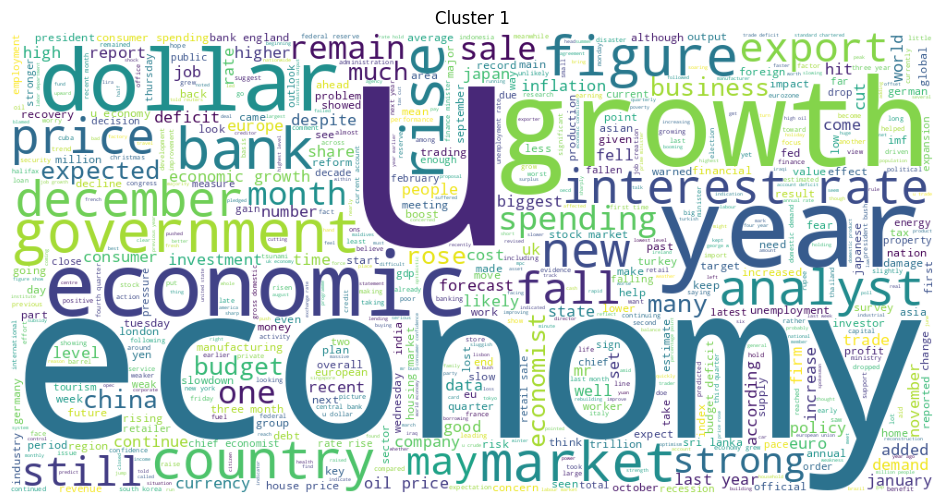

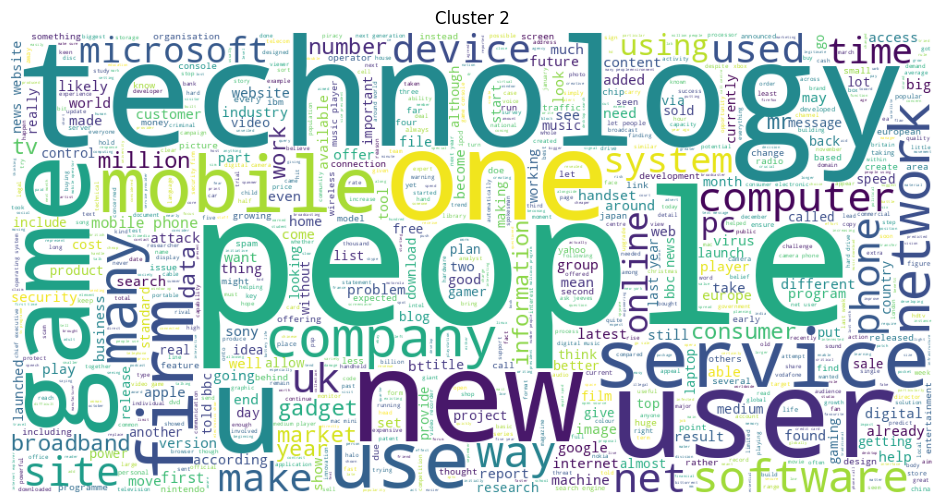

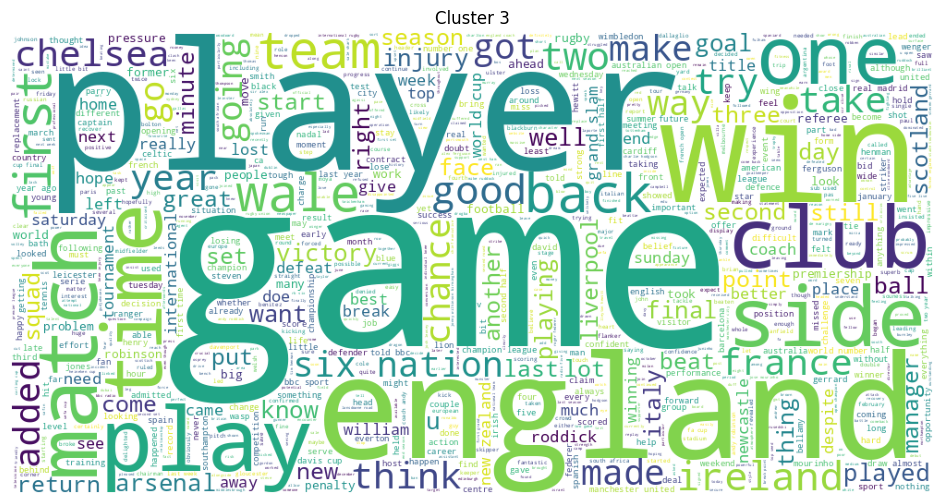

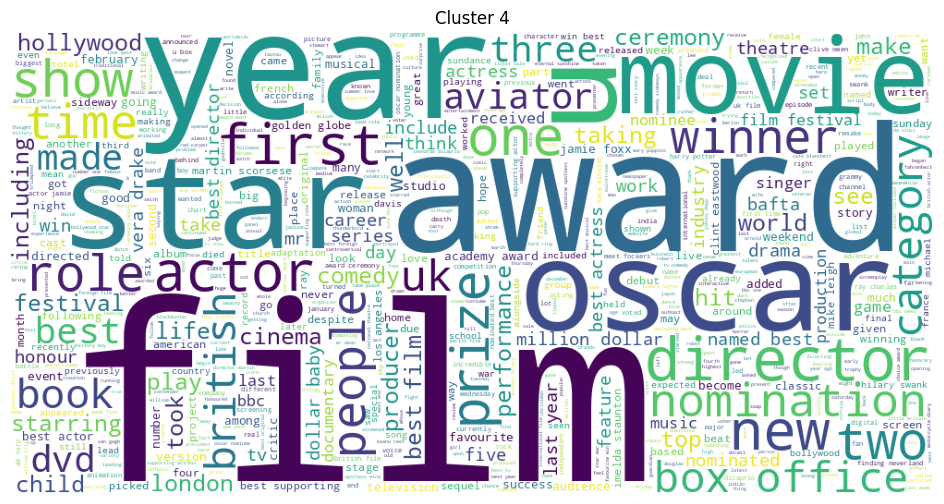

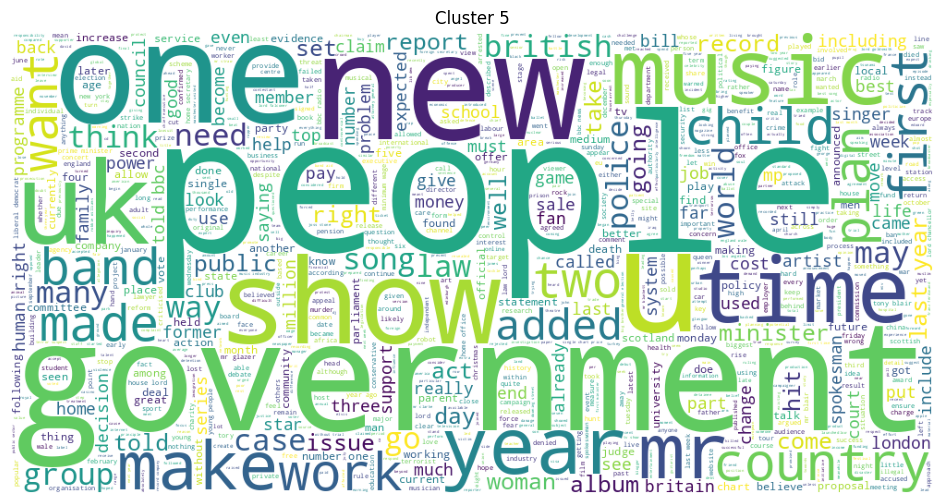

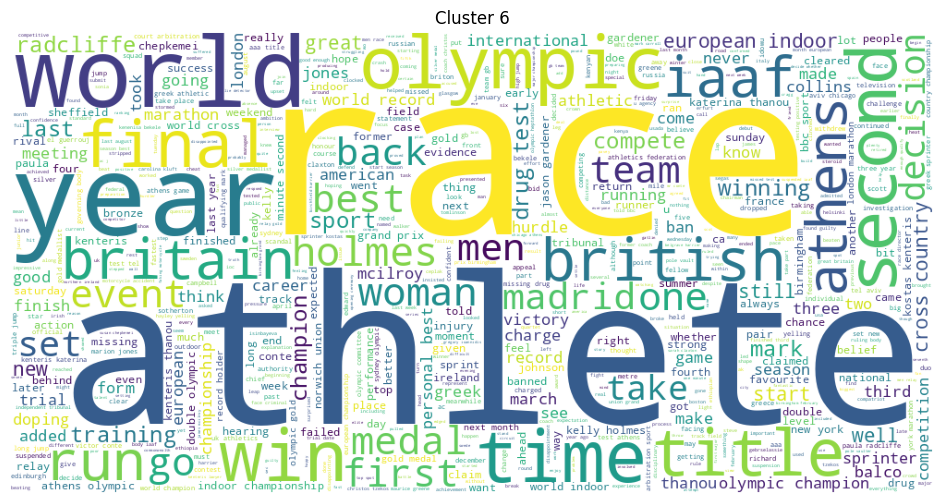

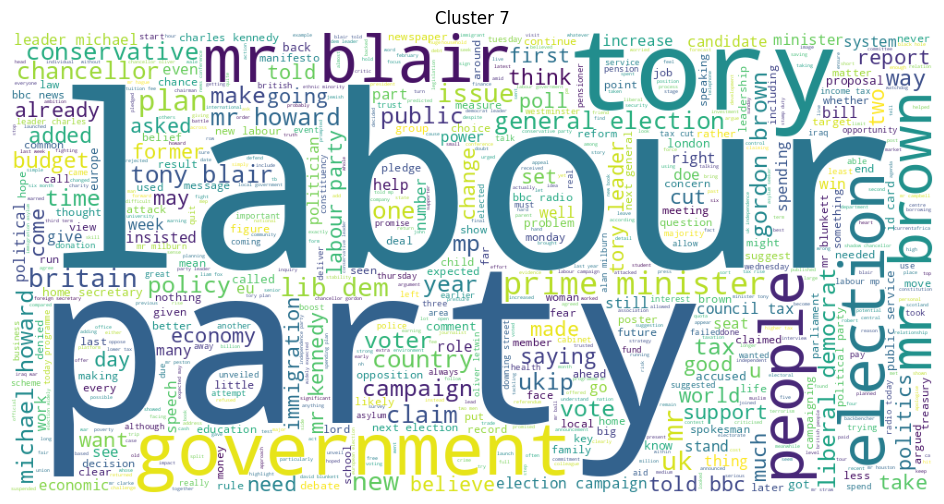

In [57]:
import matplotlib.pyplot as plt

for cluster in range(n_clusters):
    plt.figure(figsize=(12, 6))

    wordcloud = draw_wordcloud(
        data[data['cluster'] == cluster]['text']
    )

    plt.imshow(wordcloud)
    plt.axis('off')
    plt.title(f'Cluster {cluster}')
    plt.show()

Получились ли темы интерпретируемыми? Попробуйте озаглавить каждую тему.

**Ответ:**внутри кластеров преобладают слова, относящиеся к одной предметной области. поэтому TF-IDF и K-Means смогли достаточно хорошо разделить похожие по содержанию статьи

**Задание 2.2 (0.5 балла).** Попробуем другой способ выделить ключевые слова для каждой темы. Помимо непосредственного разбиения объектов алгоритм K-Means получает центр каждого кластера. Попробуйте взять центры кластеров и посмотреть на слова, для которых значения соответствующих им признаков максимальны.

In [58]:
feature_names = tfidf.get_feature_names_out()

n_top_words = 15

for cluster_id, center in enumerate(kmeans.cluster_centers_):
    top_indices = center.argsort()[-n_top_words:][::-1]
    top_words = feature_names[top_indices]

    print(f"Cluster {cluster_id}:")
    print(", ".join(top_words))
    print()

Cluster 0:
company, firm, share, profit, sale, yukos, market, airline, mr, bank, year, deal, oil, business, executive

Cluster 1:
economy, growth, rate, economic, price, bank, dollar, market, year, figure, rise, deficit, export, spending, economist

Cluster 2:
mobile, phone, technology, people, user, service, computer, software, game, digital, net, broadband, microsoft, network, site

Cluster 3:
game, england, player, match, win, cup, club, play, side, injury, chelsea, wale, rugby, team, coach

Cluster 4:
film, award, best, oscar, actor, star, festival, director, actress, movie, nomination, comedy, year, prize, aviator

Cluster 5:
mr, music, show, band, government, would, year, lord, people, uk, album, new, one, minister, also

Cluster 6:
olympic, race, indoor, athens, athletics, athlete, world, holmes, champion, iaaf, kenteris, championship, medal, thanou, marathon

Cluster 7:
mr, labour, election, party, blair, tory, brown, tax, howard, would, minister, government, chancellor, prime,

Согласуются ли полученные слова с облаками тегов из прошлого задания?

**Ответ:**В обоих случаях для каждого кластера выделяются слова одной тематики, поэтому общий смысл кластеров сохраняется.

**Задание 2.3 (1.5 балла).** В первой части мы сравнили три разных алгоритма кластеризации на географических данных. Проделаем то же самое для текстовых данных (в качестве признакого описания снова используем tf-idf). Получите три разбиения на кластеры с помощью алгоритмов K-Means, DBSCAN и спектральной кластеризации (на этот раз воспользуйтесь реализацией из `sklearn`). Для K-Means и спектральной кластеризации возьмите одинаковое небольшое число кластеров, подберите параметр `eps` метода DBSCAN так, чтобы получить приблизительно такое же число кластеров (подумайте, как это можно сделать)

Далее, обучите двухмерные t-SNE представления над tf-idf признаками текстов. Визуализируйте эти представления для каждого алгоритма, раскрасив каждый кластер своим цветом. Лучше всего расположить визуализации на одном графике на трех разных сабплотах. Не забудьте, что DBSCAN помечает некоторые точки как шумовые (можно раскрасить их в отдельный цвет).

In [ ]:
#по сути можем просто перебрать разные eps и посмотреть, сколько кластеров получается

In [59]:
def find_best_eps(X, target_clusters=8):
    results = []

    for eps in np.arange(0.1, 1.0, 0.05):
        dbscan = DBSCAN(
            eps=eps,
            min_samples=5,
            metric='cosine'
        )

        labels = dbscan.fit_predict(X)

        # -1 — это шум, поэтому его кластером не считаем
        clusters = set(labels)
        n_clusters_found = len(clusters) - (1 if -1 in clusters else 0)

        noise_ratio = np.mean(labels == -1)

        results.append(
            (eps, n_clusters_found, noise_ratio)
        )

    # Ищем eps, при котором число кластеров
    # ближе всего к требуемому
    best = min(
        results,
        key=lambda x: abs(x[1] - target_clusters)
    )

    return best, results

In [60]:
best, dbscan_results = find_best_eps(
    X_tfidf,
    target_clusters=n_clusters
)

best_eps, found_clusters, noise_ratio = best

print("Лучший eps:", best_eps)
print("Количество кластеров:", found_clusters)
print("Доля шума:", noise_ratio)

Лучший eps: 0.3500000000000001
Количество кластеров: 8
Доля шума: 0.9748314606741573


In [61]:
for eps, n, noise in dbscan_results:
    print(
        f"eps={eps:.2f} | "
        f"clusters={n} | "
        f"noise={noise:.2%}"
    )

eps=0.10 | clusters=0 | noise=100.00%
eps=0.15 | clusters=0 | noise=100.00%
eps=0.20 | clusters=0 | noise=100.00%
eps=0.25 | clusters=1 | noise=99.78%
eps=0.30 | clusters=3 | noise=99.19%
eps=0.35 | clusters=8 | noise=97.48%
eps=0.40 | clusters=10 | noise=96.31%
eps=0.45 | clusters=21 | noise=93.44%
eps=0.50 | clusters=37 | noise=87.73%
eps=0.55 | clusters=42 | noise=81.66%
eps=0.60 | clusters=61 | noise=70.34%
eps=0.65 | clusters=59 | noise=53.75%
eps=0.70 | clusters=28 | noise=37.98%
eps=0.75 | clusters=14 | noise=21.71%
eps=0.80 | clusters=2 | noise=7.10%
eps=0.85 | clusters=1 | noise=0.54%
eps=0.90 | clusters=1 | noise=0.00%
eps=0.95 | clusters=1 | noise=0.00%


In [62]:
dbscan = DBSCAN(
    eps=best_eps,
    min_samples=5,
    metric='cosine'
)

labels_dbscan = dbscan.fit_predict(X_tfidf)

Прокомментируйте получившиеся результаты. Какой баланс кластеров получился у разных методов? Соотносятся ли визуализации для текстов с визуализациями для географических данных?

**Ответ:**K-Means и спектральная кластеризация дают более сбалансированное разбиение. У DBSCAN разбиение обычно менее равномерное

**Задание 2.4 (1.5 балла).** Обучите модель латентного размещения Дирихле. Не забудьте, что она работает с мешком слов, а не с tf-idf признаками. Придумайте, как превратить распределение тем для текста в номер его кластера. Возьмите параметр `n_components` в 2-3 раза больше, чем число кластеров для K-Means.

In [ ]:
#нужно добавить LDA и ей нужна матрица количества слов

In [64]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

count_vectorizer = CountVectorizer(
    min_df=5,
    max_df=0.9
)

X_bow = count_vectorizer.fit_transform(data['text'])

print(X_bow.shape)

(2225, 7822)


Обучаем LDA

In [65]:
n_topics = 20

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method='batch'
)

X_lda = lda.fit_transform(X_bow)

print(X_lda.shape)

(2225, 20)


Превращаем распределение тем в номер кластера

In [68]:
labels_lda = X_lda.argmax(axis=1)
print(len(labels_lda))
print(len(data))

unique, counts = np.unique(
    labels_lda,
    return_counts=True
)

for topic, count in zip(unique, counts):
    print(f"Topic {topic}: {count} документов")

2225
2225
Topic 0: 123 документов
Topic 1: 55 документов
Topic 2: 227 документов
Topic 3: 86 документов
Topic 4: 97 документов
Topic 5: 18 документов
Topic 6: 198 документов
Topic 7: 42 документов
Topic 8: 37 документов
Topic 9: 87 документов
Topic 10: 195 документов
Topic 11: 43 документов
Topic 12: 274 документов
Topic 13: 34 документов
Topic 14: 27 документов
Topic 15: 97 документов
Topic 16: 37 документов
Topic 17: 288 документов
Topic 18: 76 документов
Topic 19: 184 документов


In [69]:
feature_names = count_vectorizer.get_feature_names_out()

n_top_words = 10

for topic_idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[-n_top_words:][::-1]
    top_words = feature_names[top_indices]

    print(
        f"Topic {topic_idx}:",
        ", ".join(top_words)
    )

Topic 0: law, would, police, government, right, home, lord, mr, case, court
Topic 1: people, school, ukip, chelsea, would, party, could, education, child, time
Topic 2: mr, labour, would, party, election, blair, minister, government, tory, people
Topic 3: club, united, goal, football, liverpool, would, manager, manchester, league, chelsea
Topic 4: software, computer, search, system, microsoft, user, information, program, security, people
Topic 5: airline, flight, mci, passenger, independent, share, company, year, newspaper, cut
Topic 6: year, economy, growth, rate, economic, price, rise, month, country, market
Topic 7: would, bid, offer, year, deutsche, lse, also, new, proposal, boerse
Topic 8: mr, fraud, company, former, executive, new, fiat, chief, ebbers, charge
Topic 9: company, oil, yukos, firm, india, government, court, state, russian, country
Topic 10: share, sale, year, company, market, firm, bank, new, profit, also
Topic 11: drug, virus, spam, test, athens, attack, site, also,

In [71]:
count_vectorizer = CountVectorizer(
    min_df=5,
    max_df=0.9
)

X_bow = count_vectorizer.fit_transform(data['text'])


n_topics = 20

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method='batch'
)
X_lda = lda.fit_transform(X_bow)

labels_lda = np.argmax(X_lda, axis=1)

unique, counts = np.unique(labels_lda, return_counts=True)

for topic, count in zip(unique, counts):
    print(f"Topic {topic}: {count} документов")

Topic 0: 123 документов
Topic 1: 55 документов
Topic 2: 227 документов
Topic 3: 86 документов
Topic 4: 97 документов
Topic 5: 18 документов
Topic 6: 198 документов
Topic 7: 42 документов
Topic 8: 37 документов
Topic 9: 87 документов
Topic 10: 195 документов
Topic 11: 43 документов
Topic 12: 274 документов
Topic 13: 34 документов
Topic 14: 27 документов
Topic 15: 97 документов
Topic 16: 37 документов
Topic 17: 288 документов
Topic 18: 76 документов
Topic 19: 184 документов


Получились ли темы более узкими от такого нововведения? Постройте облака тегов для нескольких наиболее удачных тем.

**Ответ:**Да, темы стали более узкими и специализированными тк в LDA было задано больше тем, чем кластеров в K-Means поэтому крупные общие тематики разделились на несколько более конкретных

In [72]:
feature_names = count_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[-10:][::-1]
    top_words = feature_names[top_indices]

    print(f"Topic {topic_idx}: {', '.join(top_words)}")

Topic 0: law, would, police, government, right, home, lord, mr, case, court
Topic 1: people, school, ukip, chelsea, would, party, could, education, child, time
Topic 2: mr, labour, would, party, election, blair, minister, government, tory, people
Topic 3: club, united, goal, football, liverpool, would, manager, manchester, league, chelsea
Topic 4: software, computer, search, system, microsoft, user, information, program, security, people
Topic 5: airline, flight, mci, passenger, independent, share, company, year, newspaper, cut
Topic 6: year, economy, growth, rate, economic, price, rise, month, country, market
Topic 7: would, bid, offer, year, deutsche, lse, also, new, proposal, boerse
Topic 8: mr, fraud, company, former, executive, new, fiat, chief, ebbers, charge
Topic 9: company, oil, yukos, firm, india, government, court, state, russian, country
Topic 10: share, sale, year, company, market, firm, bank, new, profit, also
Topic 11: drug, virus, spam, test, athens, attack, site, also,

## Часть 3. Transfer learning и Self-Supervised Learning для задачи классификации текстов

**Задание 3.1 (0.5 балла).** Вспомним, что у нас есть разметка для тематик статей. Попробуем обучить классификатор поверх unsupervised-представлений для текстов. Рассмотрите три модели:

* Логистическая регрессия на tf-idf признаках
* K-Means на tf-idf признаках + логистическая регрессия на расстояниях до центров кластеров
* Латентное размещение Дирихле + логистическая регрессия на вероятностях тем

Разделите выборку на обучающую и тестовую, замерьте accuracy на обоих выборках для всех трех моделей. Параметры всех моделей возьмите равными значениям по умолчанию.

In [ ]:
# YOUR CODE HERE ‿︵‿︵ヽ(°□° )ノ︵‿︵‿

У какой модели получилось лучшее качество? С чем это связано?

**Ответ:**

**Задание 3.2 (1.5 балла).** Теперь просимулируем ситуацию слабой разметки, которая часто встречается в реальных данных. Разделим обучающую выборку в пропорции 5:65:30. Будем называть части, соответственно, размеченный трейн, неразмеченный трейн и валидация.

Все unsupervised-алгоритмы (векторайзеры и алгоритмы кластеризации) запускайте на всем трейне целиком (размеченном и неразмеченном, суммарно 70%), а итоговый классификатор обучайте только на размеченном трейне (5%). Подберите гиперпараметры моделей по качеству на валидации (30%), а затем оцените качество на тестовой выборке (которая осталась от прошлого задания). Не скромничайте при подборе числа кластеров, сейчас нас интересует не интерпретируемое разбиение выборки, а итоговое качество классификации.

In [ ]:
#Нужно сдеать ерэин и тест до обучения TF и BOW

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X_train_text, X_test_text, y_train, y_test = train_test_split(
    data['text'],
    data['category'],
    test_size=0.2,
    random_state=42,
    stratify=data['category']
)

print("Train:", len(X_train_text))
print("Test:", len(X_test_text))

Train: 1780
Test: 445


Лог регрессия на TF-IDF

In [76]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

lr_tfidf = LogisticRegression()
lr_tfidf.fit(X_train_tfidf, y_train)

train_pred_tfidf = lr_tfidf.predict(X_train_tfidf)
test_pred_tfidf = lr_tfidf.predict(X_test_tfidf)

train_acc_tfidf = accuracy_score(
    y_train,
    train_pred_tfidf
)

test_acc_tfidf = accuracy_score(
    y_test,
    test_pred_tfidf
)

print("Train accuracy:", train_acc_tfidf)
print("Test accuracy:", test_acc_tfidf)

Train accuracy: 0.9971910112359551
Test accuracy: 0.9887640449438202


K-Means and Logistic Regression

In [78]:
kmeans = KMeans()
kmeans.fit(X_train_tfidf)

X_train_kmeans = kmeans.transform(X_train_tfidf)
X_test_kmeans = kmeans.transform(X_test_tfidf)

print(X_train_kmeans.shape)

(1780, 8)


Обучаем классификатор:

In [79]:
lr_kmeans = LogisticRegression()

lr_kmeans.fit(
    X_train_kmeans,
    y_train
)

train_pred_kmeans = lr_kmeans.predict(
    X_train_kmeans
)

test_pred_kmeans = lr_kmeans.predict(
    X_test_kmeans
)

train_acc_kmeans = accuracy_score(
    y_train,
    train_pred_kmeans
)

test_acc_kmeans = accuracy_score(
    y_test,
    test_pred_kmeans
)

print("Train accuracy:", train_acc_kmeans)
print("Test accuracy:", test_acc_kmeans)

Train accuracy: 0.7556179775280899
Test accuracy: 0.7595505617977528


In [80]:
count_vectorizer = CountVectorizer()

X_train_bow = count_vectorizer.fit_transform(
    X_train_text
)

X_test_bow = count_vectorizer.transform(
    X_test_text
)

обучаем LDA

In [81]:
lda = LatentDirichletAllocation()

X_train_lda = lda.fit_transform(
    X_train_bow
)

X_test_lda = lda.transform(
    X_test_bow
)

print(X_train_lda.shape)

(1780, 10)


передаем признаки в лог рег

In [82]:
lr_lda = LogisticRegression()

lr_lda.fit(
    X_train_lda,
    y_train
)

train_pred_lda = lr_lda.predict(
    X_train_lda
)

test_pred_lda = lr_lda.predict(
    X_test_lda
)

train_acc_lda = accuracy_score(
    y_train,
    train_pred_lda
)

test_acc_lda = accuracy_score(
    y_test,
    test_pred_lda
)

print("Train accuracy:", train_acc_lda)
print("Test accuracy:", test_acc_lda)

Train accuracy: 0.9078651685393259
Test accuracy: 0.9438202247191011


In [83]:
results = pd.DataFrame({
    'Model': [
        'TF-IDF + Logistic Regression',
        'K-Means + Logistic Regression',
        'LDA + Logistic Regression'
    ],
    'Train Accuracy': [
        train_acc_tfidf,
        train_acc_kmeans,
        train_acc_lda
    ],
    'Test Accuracy': [
        test_acc_tfidf,
        test_acc_kmeans,
        test_acc_lda
    ]
})

results

,Model,Train Accuracy,Test Accuracy
0,TF-IDF + Logistic Regression,0.997191,0.988764
1,K-Means + Logistic Regression,0.755618,0.759551
2,LDA + Logistic Regression,0.907865,0.943820


Как изменились результаты по сравнению с обучением на полной разметке? Сделайте выводы.

**Ответ:**исходные TF-IDF-признаки хорошо сохраняют информацию
K-Means + Logistic Regression работает значительно хуже
ля классификации здесь лучше всего использовать TF-IDF-признаки

## Бонус

**Задание 4 (0.5 балла)**. Разберитесь с semi-supervised методами, которые реализованы в `sklearn` и примените их к заданию 3.2. Получилось ли добиться лучшего качества? Сделайте выводы.

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.semi_supervised import (
    SelfTrainingClassifier,
    LabelPropagation,
    LabelSpreading
)
from sklearn.metrics import accuracy_score


X_semi, X_val, y_semi_true, y_val = train_test_split(
    X_train_text,
    y_train,
    test_size=0.30,
    random_state=42,
    stratify=y_train
)



X_labeled, X_unlabeled, y_labeled, y_unlabeled_true = train_test_split(
    X_semi,
    y_semi_true,
    train_size=5/70,
    random_state=42,
    stratify=y_semi_true
)

print("Labeled:", len(X_labeled))
print("Unlabeled:", len(X_unlabeled))
print("Validation:", len(X_val))
print("Test:", len(X_test_text))

Labeled: 89
Unlabeled: 1157
Validation: 534
Test: 445


In [85]:
X_all_train_text = pd.concat([
    X_labeled,
    X_unlabeled
])

tfidf_semi = TfidfVectorizer()

X_all_train = tfidf_semi.fit_transform(X_all_train_text)
X_labeled_tfidf = tfidf_semi.transform(X_labeled)
X_val_tfidf = tfidf_semi.transform(X_val)
X_test_tfidf = tfidf_semi.transform(X_test_text)

In [86]:
encoder = LabelEncoder()

encoder.fit(y_train)

y_labeled_enc = encoder.transform(y_labeled)
y_val_enc = encoder.transform(y_val)
y_test_enc = encoder.transform(y_test)

# Первые len(X_labeled) объектов имеют настоящие метки.
# Все остальные считаются неразмеченными.
y_semi = np.full(
    X_all_train.shape[0],
    -1,
    dtype=int
)

y_semi[:len(X_labeled)] = y_labeled_enc

print("Размечено:", np.sum(y_semi != -1))
print("Не размечено:", np.sum(y_semi == -1))

Размечено: 89
Не размечено: 1157


In [87]:
baseline = LogisticRegression()

baseline.fit(
    X_labeled_tfidf,
    y_labeled_enc
)

baseline_val = accuracy_score(
    y_val_enc,
    baseline.predict(X_val_tfidf)
)

baseline_test = accuracy_score(
    y_test_enc,
    baseline.predict(X_test_tfidf)
)

print("Baseline val:", baseline_val)
print("Baseline test:", baseline_test)

Baseline val: 0.7921348314606742
Baseline test: 0.8067415730337079


In [88]:
self_training_results = []

for threshold in [0.6, 0.7, 0.8, 0.9, 0.95]:
    model = SelfTrainingClassifier(
        LogisticRegression(),
        threshold=threshold
    )

    model.fit(X_all_train, y_semi)

    val_acc = accuracy_score(
        y_val_enc,
        model.predict(X_val_tfidf)
    )

    self_training_results.append(
        (threshold, val_acc)
    )

    print(
        f"threshold={threshold}: "
        f"val accuracy={val_acc:.4f}"
    )

threshold=0.6: val accuracy=0.7921
threshold=0.7: val accuracy=0.7921
threshold=0.8: val accuracy=0.7921
threshold=0.9: val accuracy=0.7921
threshold=0.95: val accuracy=0.7921


In [89]:
best_threshold, best_self_val = max(
    self_training_results,
    key=lambda x: x[1]
)

self_training = SelfTrainingClassifier(
    LogisticRegression(),
    threshold=best_threshold
)

self_training.fit(
    X_all_train,
    y_semi
)

self_test = accuracy_score(
    y_test_enc,
    self_training.predict(X_test_tfidf)
)

print("Best threshold:", best_threshold)
print("SelfTraining val:", best_self_val)
print("SelfTraining test:", self_test)

Best threshold: 0.6
SelfTraining val: 0.7921348314606742
SelfTraining test: 0.8067415730337079


**Задание 5 (0.5 балла)**. На занятиях мы обсуждали, что метрика [BCubed](https://www.researchgate.net/profile/Julio-Gonzalo-2/publication/225548032_Amigo_E_Gonzalo_J_Artiles_J_et_alA_comparison_of_extrinsic_clustering_evaluation_metrics_based_on_formal_constraints_Inform_Retriev_12461-486/links/0c96052138dbb99740000000/Amigo-E-Gonzalo-J-Artiles-J-et-alA-comparison-of-extrinsic-clustering-evaluation-metrics-based-on-formal-constraints-Inform-Retriev-12461-486.pdf) хорошо подходит для сравнения алгоритмов кластеризации, если нам известно настоящее разделение на кластеры (gold standard). Реализуйте подсчет метрики BCubed и сравните несколько алгоритмов кластеризации на текстовых данных из основного задания. В качестве gold standard используйте разметку category.

In [ ]:
# YOUR CODE HERE ‿︵‿︵ヽ(°□° )ノ︵‿︵‿

**Задание 6 (1 балл)**. Спектральная кластеризация, по сути, является обычной кластеризацией KMeans поверх эмбеддингов объектов, которые получаются из лапласиана графа. А что, если мы попробуем построить эмбеддинги каким-нибудь другим способом? В этом задании мы предлагаем вам проявить немного фантазии. Возьмите какие-нибудь данные высокой размерности, чтобы задача обучения эмбеддингов имела смысл (например, картинки или тексты, желательно выбрать что-нибудь оригинальное). Придумайте или найдите какой-нибудь метод обучения эмбеддингов, примените его к данным и кластеризуйте полученные представления. Если чувствуете в себе достаточно силы, можете попробовать что-нибудь нейросетевое. Сравните ваш подход с базовыми алгоритмами кластеризации, которое мы рассмотрели в основном задании, не забывайте про визуализации! Ключевые слова для вдохновения: ***KernelPCA***, ***UMAP***, ***autoencoders***, ***gensim***.

In [ ]:
# YOUR CODE HERE ‿︵‿︵ヽ(°□° )ノ︵‿︵‿

**Задание 7 (0.5 балла)**. Наконец, ставший ежегодной традицией социализационный бонус. Мы поощряем не только предметное, но и духовное развитие. Поэтому, чтобы заработать полбалла за это задание, сходите на какую-нибудь выставку, в музей, театр, или наконец в церковь, напишите небольшой отчетик о ваших впечатлениях и добавьте фотопруфы в ноутбук при сдаче. Можете объединиться с одногруппниками/однокурсниками, а также пригласить ассистентов/преподавателей, они тоже будут рады выбраться куда-нибудь. Для вдохновения приведем ссылку на актуальные выставки [новой](https://www.youtube.com/watch?v=dQw4w9WgXcQ&ab) и [старой Третьяковки](https://www.youtube.com/watch?v=X1-MXdyThJ0) (но совсем не обязательно посещать именно их).

In [ ]:
# YOUR CODE HERE (ノಠ益ಠ)ノ彡┻━┻